# No-data & gap filling

Manage the cells that don't hold real data:

- **`change_no_data_value`** — change the no-data sentinel (e.g. `-9999` → `NaN`).
- **`fill`** — set every in-domain cell to a constant value.
- **`fill_gaps`** — interpolate holes in one raster using another raster's valid domain
  (nearest-neighbour).

## Setup

In [1]:
%matplotlib inline

import shutil
import tempfile
from pathlib import Path

import numpy as np

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-t2-'))
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset

ds = Dataset.read_file(DATA / 'acc4000.tif')
ds.shape, ds.no_data_value

2026-07-13 23:23:51 | INFO | pyramids.base.config | Logging is configured.


((1, 13, 14), (-3.4028230607370965e+38,))

The source raster — no-data cells render as blanks against the valid domain.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:816: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


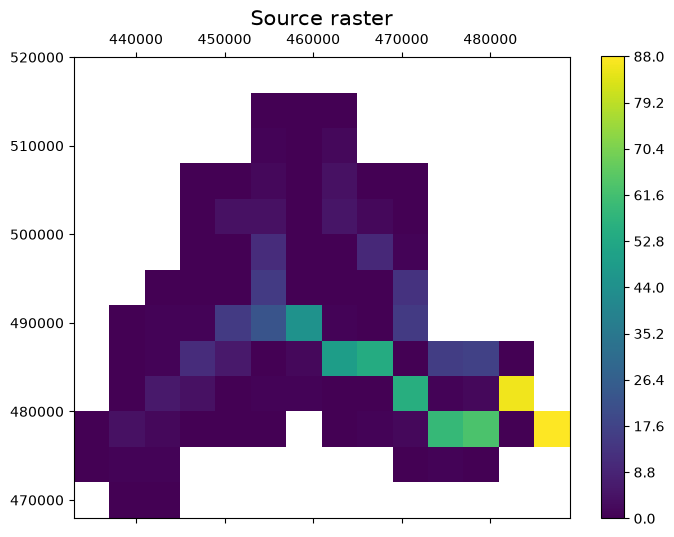

In [3]:
ds.plot(band=0, title="Source raster", cmap="viridis")

## Change the no-data sentinel — `change_no_data_value`

Re-label the sentinel that marks empty cells.

In [4]:
relabelled = ds.change_no_data_value(-1.0)
ds.no_data_value[0], '->', relabelled.no_data_value[0]

(-3.4028230607370965e+38, '->', np.float64(-1.0))

## Fill the domain — `fill`

Replace every valid cell with a constant (no-data cells stay no-data).

In [5]:
filled = ds.fill(5.0)
valid = filled.read_array()
float(np.nanmax(np.where(valid == filled.no_data_value[0], np.nan, valid)))

5.0

## Interpolate holes — `fill_gaps`

`fill_gaps(mask, src_array)` fills cells that are no-data in the source but valid in the
`mask` dataset, using nearest-neighbour interpolation. Below, a 5×5 grid with two punched
holes is repaired against a hole-free mask.

In [6]:
ND = -9999.0
base = np.arange(1, 26, dtype='float32').reshape(5, 5)
holed = base.copy()
holed[2, 2] = ND
holed[1, 3] = ND
src = Dataset.create_from_array(
    holed, top_left_corner=(0, 0), cell_size=1.0, epsg=4326, no_data_value=ND
)
mask = Dataset.create_from_array(
    base, top_left_corner=(0, 0), cell_size=1.0, epsg=4326, no_data_value=ND
)
repaired = np.asarray(src.fill_gaps(mask, src.read_array())).squeeze()
int((holed == ND).sum()), '->', int((repaired == ND).sum()), '| repaired[2,2] =', float(
    repaired[2, 2]
)

(2, '->', 0, '| repaired[2,2] =', 14.0)

Before & after: `src` has two punched holes (the blank cells); the repaired grid is hole-free.
The repaired array is wrapped back into a `Dataset` so it can be plotted the same way.

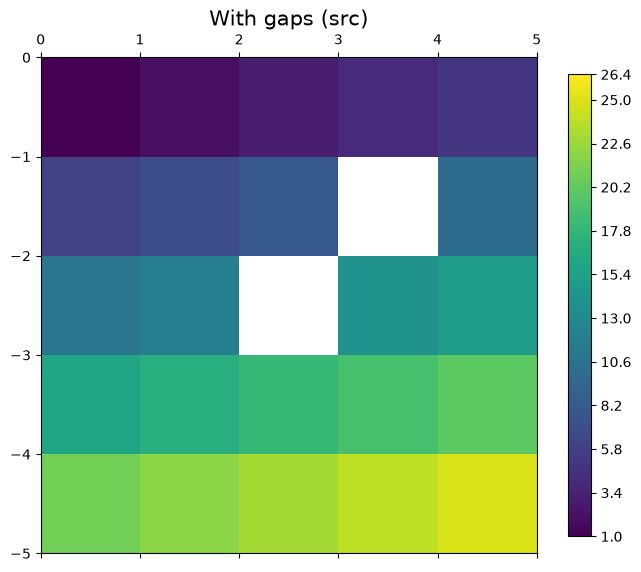

In [7]:
src.plot(band=0, title="With gaps (src)", cmap="viridis")

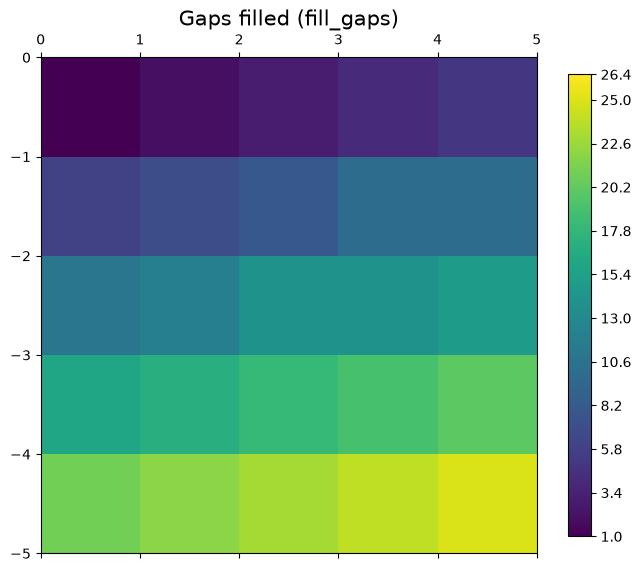

In [8]:
repaired_ds = Dataset.create_from_array(
    repaired.astype('float32'), top_left_corner=(0, 0), cell_size=1.0, epsg=4326, no_data_value=ND
)
repaired_ds.plot(band=0, title="Gaps filled (fill_gaps)", cmap="viridis")

## Notes

- `change_no_data_value` and `fill` take `inplace=True` to mutate the dataset in place.
- `fill_gaps` is the building block behind aligned crops that repair edge gaps.
- See also: [Crop & mask](crop-mask.ipynb).